## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, accuracy_score
import os
from PIL import Image

## Set up Environment

In [ ]:
#Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
NUM_EPOCHS = 30
NUM_FOLDS = 5

## Set up Paths

In [ ]:
DATA_DIR = '/content/drive/MyDrive/Wound_Assessment/data/segmented_images/Segmented_Dataset_Final_v2/'
LABELS_CSV = '/content/drive/MyDrive/Wound_Assessment/data/metadata/metadata_with_folds.csv'

## Define Models

In [ ]:
df_expert = pd.read_csv(LABELS_CSV)

model_families = ['efficientnet_b0', 'resnet50', 'mobilenet_v3', 'swin_t']

print(f"Dataframe loaded with {len(df_expert)} images.")
print(f"Model comparison list: {model_families}")

Dataframe loaded with 107 images.
Model comparison list: ['efficientnet_b0', 'resnet50', 'mobilenet_v3', 'swin_t']


## Multi-Taski Dataset Class

In [ ]:
class WoundComparisonDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['filename']
        img_path = os.path.join(DATA_DIR, img_name)
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found at {img_path}.")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        inf = torch.tensor(int(row['Final_Inf']), dtype=torch.long)
        moist = torch.tensor(int(row['Final_Moist']), dtype=torch.long)
        edge = torch.tensor(int(row['Final_Edge']), dtype=torch.long)

        return image, inf, moist, edge

## Data Augmentation

In [ ]:
IMG_SIZE = 224

data_transforms = {
    'train': transforms.Compose([
        # 1. Standardize Size
        transforms.Resize((IMG_SIZE, IMG_SIZE)),

        # 2. Data Augmentation
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),

        # 3. Formatting
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    'val': transforms.Compose([
        # Standardize size for validation as well
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print(f"Data Augmentation is ready.")

Data Augmentation is ready.


## Model Comparison

In [ ]:
class ModelBackboneComparison(nn.Module):
    def __init__(self, model_type):
        super(ModelBackboneComparison, self).__init__()
        self.model_type = model_type

        if model_type == 'efficientnet_b0':
            base = models.efficientnet_b0(weights='IMAGENET1K_V1')
            self.backbone = base.features
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.feat_dim = 1280

        elif model_type == 'resnet50':
            base = models.resnet50(weights='IMAGENET1K_V1')
            self.backbone = nn.Sequential(*list(base.children())[:-1])
            self.feat_dim = 2048

        elif model_type == 'mobilenet_v3':
            base = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
            self.backbone = base.features
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.feat_dim = 960

        elif model_type == 'swin_t':
            base = models.swin_t(weights='IMAGENET1K_V1')
            self.backbone = nn.Sequential(base.features, base.norm, base.permute, base.avgpool)
            self.feat_dim = 768

        # Identical Task Heads
        self.head_inf = nn.Linear(self.feat_dim, 2)
        self.head_moist = nn.Linear(self.feat_dim, 3)
        self.head_edge = nn.Linear(self.feat_dim, 2)

    def forward(self, x):
        x = self.backbone(x)
        if 'swin' not in self.model_type and hasattr(self, 'pool'):
            x = self.pool(x)
        # Flatten the tensor for the linear layers regardless of the model type.
        x = torch.flatten(x, 1)
        return self.head_inf(x), self.head_moist(x), self.head_edge(x)

## Calculate Class Weights

In [ ]:
def calculate_task_weights(df, column_name):
    # Only look at valid labels (exclude -1)
    valid_data = df[df[column_name] != -1][column_name]

    # Count occurrences of each class
    class_counts = valid_data.value_counts().sort_index().values
    num_samples = len(valid_data)
    num_classes = len(class_counts)

    # Compute Inverse Frequency: Total_Samples / (Num_Classes * Class_Samples)
    weights = num_samples / (num_classes * class_counts)

    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

# Calculate weights for all 3 tasks
weights_inf = calculate_task_weights(df_expert, 'Final_Inf')
weights_moist = calculate_task_weights(df_expert, 'Final_Moist')
weights_edge = calculate_task_weights(df_expert, 'Final_Edge')

print(f"Infection Weights (Not Inf vs Inf): {weights_inf}")
print(f"Moisture Weights (Dry vs Mod vs Wet): {weights_moist}")
print(f"Edge Weights (Not Adv vs Adv): {weights_edge}")

Infection Weights (Not Inf vs Inf): tensor([0.7465, 1.5143], device='cuda:0')
Moisture Weights (Dry vs Mod vs Wet): tensor([2.7436, 0.4573, 2.2292], device='cuda:0')
Edge Weights (Not Adv vs Adv): tensor([1.7000, 0.7083], device='cuda:0')


## Define Loss Function and Optimizer

### Weighted Loss

In [ ]:
# Weighted Cross-Entropy (For Imbalance)
criterion_inf = nn.CrossEntropyLoss(weight=weights_inf, ignore_index=-1)
criterion_moist = nn.CrossEntropyLoss(weight=weights_moist, ignore_index=-1)
criterion_edge = nn.CrossEntropyLoss(weight=weights_edge, ignore_index=-1)

## Model Training

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for images, inf_labels, moist_labels, edge_labels in loader:
        images = images.to(device)
        inf_labels = inf_labels.to(device)
        moist_labels = moist_labels.to(device)
        edge_labels = edge_labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        out_inf, out_moist, out_edge = model(images)

        # Calculate losses
        loss_inf = criterion_inf(out_inf, inf_labels)
        loss_moist = criterion_moist(out_moist, moist_labels)
        loss_edge = criterion_edge(out_edge, edge_labels)

        # Combined Loss
        batch_loss = loss_inf + loss_moist + loss_edge

        batch_loss.backward()
        optimizer.step()

        total_loss += batch_loss.item()

    return total_loss / len(loader)

## Validation

In [ ]:
from sklearn.metrics import recall_score, f1_score

def validate_one_epoch(model, loader, device):
    model.eval()
    results = {
        'inf': {'preds': [], 'labels': []},
        'moist': {'preds': [], 'labels': []},
        'edge': {'preds': [], 'labels': []}
    }

    val_loss = 0

    with torch.no_grad():
        for images, inf_l, moist_l, edge_l in loader:
            images = images.to(device)
            inf_l, moist_l, edge_l = inf_l.to(device), moist_l.to(device), edge_l.to(device)

            # Forward pass
            out_inf, out_moist, out_edge = model(images)

            # Calculate validation loss
            loss_inf = criterion_inf(out_inf, inf_l)
            loss_moist = criterion_moist(out_moist, moist_l)
            loss_edge = criterion_edge(out_edge, edge_l)
            val_loss += (loss_inf + loss_moist + loss_edge).item()

            # Extract outputs for metric calculation
            tasks = ['inf', 'moist', 'edge']
            outputs = [out_inf, out_moist, out_edge]
            labels_list = [inf_l, moist_l, edge_l]

            for task, output, labels in zip(tasks, outputs, labels_list):
                preds = torch.argmax(output, dim=1).cpu().numpy()
                lbls = labels.cpu().numpy()

                # Filter out -1 (Missing Data)
                mask = lbls != -1
                results[task]['preds'].extend(preds[mask])
                results[task]['labels'].extend(lbls[mask])

    # Calculate Macro metrics
    metrics = {'loss': val_loss / len(loader)}
    for task in ['inf', 'moist', 'edge']:
        metrics[f'f1_{task}'] = f1_score(results[task]['labels'], results[task]['preds'], average='macro', zero_division=0)
        metrics[f'recall_{task}'] = recall_score(results[task]['labels'], results[task]['preds'], average='macro', zero_division=0)

    return metrics

## Main Experimental Loop

In [ ]:
master_comparison_results = []

print(f"Starting Phase: Models Comparison on Device: {DEVICE}")

for model_name in model_families:
    print(f"\n{'='*60}")
    print(f"TESTING BACKBONE: {model_name.upper()}")
    print(f"{'='*60}")

    fold_metrics_summary = []

    for fold in range(NUM_FOLDS):
        print(f"\n{'='*20} STARTING FOLD {fold+1}/{NUM_FOLDS} {'='*20}")

        # Split Data
        train_df = df_expert[df_expert['fold'] != fold].reset_index(drop=True)
        val_df = df_expert[df_expert['fold'] == fold].reset_index(drop=True)

        # DataLoaders
        train_ds = WoundComparisonDataset(train_df, transform=data_transforms['train'])
        val_ds = WoundComparisonDataset(val_df, transform=data_transforms['val'])
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        # Fresh Model & Optimizer for this fold
        model = ModelBackboneComparison(model_name).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

        # Independent Task Tracking
        best_val_loss = float('inf')
        best_fold_metrics = {}

        for epoch in range(NUM_EPOCHS):
            # Training (Sum of 3 losses)
            train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

            # Validation (Independent Metrics for all 3)
            val_metrics = validate_one_epoch(model, val_loader, DEVICE)

            # Save based on TOTAL Loss
            if val_metrics['loss'] < best_val_loss:
                best_val_loss = val_metrics['loss']
                best_fold_metrics = val_metrics
                torch.save(model.state_dict(), f"best_{model_name}_fold{fold}.pth")

            # Independent Task Logging
            print(f"Ep {epoch+1:02d} | Loss: {val_metrics['loss']:.3f} | "
                  f"INF (F1:{val_metrics['f1_inf']:.2f}, Rec:{val_metrics['recall_inf']:.2f}) | "
                  f"MOIST (F1:{val_metrics['f1_moist']:.2f}, Rec:{val_metrics['recall_moist']:.2f}) | "
                  f"EDGE (F1:{val_metrics['f1_edge']:.2f}, Rec:{val_metrics['recall_edge']:.2f})")

        fold_metrics_summary.append(best_fold_metrics)
        print(f" Fold {fold+1} Finished. Best Total Val Loss: {best_val_loss:.4f}")

    # Aggregate Metrics for this model across all 5 folds
    model_entry = {'Architecture': model_name}
    for task in ['inf', 'moist', 'edge']:
        model_entry[f'F1_{task}'] = np.mean([m[f'f1_{task}'] for m in fold_metrics_summary])
        model_entry[f'Rec_{task}'] = np.mean([m[f'recall_{task}'] for m in fold_metrics_summary])

    master_comparison_results.append(model_entry)

# Final Comparison Table across all architectures
print(f"\n{'='*60}")
print(" FINAL ARCHITECTURAL COMPARISON (AVERAGE OF 5 FOLDS)")
print(f"{'='*60}")
comparison_df = pd.DataFrame(master_comparison_results)
print(comparison_df.to_string(index=False))

Starting Phase: Models Comparison on Device: cuda

TESTING BACKBONE: EFFICIENTNET_B0

==================== STARTING FOLD 1/5 ====================
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 85.3MB/s]


Ep 01 | Loss: 2.614 | INF (F1:0.53, Rec:0.60) | MOIST (F1:0.31, Rec:0.32) | EDGE (F1:0.41, Rec:0.50)
Ep 02 | Loss: 2.641 | INF (F1:0.58, Rec:0.61) | MOIST (F1:0.53, Rec:0.53) | EDGE (F1:0.51, Rec:0.52)
Ep 03 | Loss: 2.740 | INF (F1:0.58, Rec:0.61) | MOIST (F1:0.39, Rec:0.39) | EDGE (F1:0.51, Rec:0.52)
Ep 04 | Loss: 2.795 | INF (F1:0.64, Rec:0.65) | MOIST (F1:0.27, Rec:0.26) | EDGE (F1:0.51, Rec:0.52)
Ep 05 | Loss: 2.793 | INF (F1:0.64, Rec:0.65) | MOIST (F1:0.27, Rec:0.26) | EDGE (F1:0.57, Rec:0.57)
Ep 06 | Loss: 2.764 | INF (F1:0.53, Rec:0.56) | MOIST (F1:0.23, Rec:0.21) | EDGE (F1:0.57, Rec:0.57)
Ep 07 | Loss: 2.800 | INF (F1:0.53, Rec:0.56) | MOIST (F1:0.23, Rec:0.21) | EDGE (F1:0.57, Rec:0.57)
Ep 08 | Loss: 2.746 | INF (F1:0.53, Rec:0.56) | MOIST (F1:0.23, Rec:0.21) | EDGE (F1:0.53, Rec:0.53)
Ep 09 | Loss: 2.655 | INF (F1:0.53, Rec:0.56) | MOIST (F1:0.23, Rec:0.21) | EDGE (F1:0.72, Rec:0.72)
Ep 10 | Loss: 2.535 | INF (F1:0.53, Rec:0.56) | MOIST (F1:0.33, Rec:0.37) | EDGE (F1:0.80, 

100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Ep 01 | Loss: 2.980 | INF (F1:0.35, Rec:0.41) | MOIST (F1:0.27, Rec:0.31) | EDGE (F1:0.60, Rec:0.60)
Ep 02 | Loss: 3.130 | INF (F1:0.51, Rec:0.54) | MOIST (F1:0.24, Rec:0.26) | EDGE (F1:0.55, Rec:0.56)
Ep 03 | Loss: 3.240 | INF (F1:0.62, Rec:0.62) | MOIST (F1:0.36, Rec:0.42) | EDGE (F1:0.77, Rec:0.76)
Ep 04 | Loss: 3.618 | INF (F1:0.53, Rec:0.53) | MOIST (F1:0.25, Rec:0.26) | EDGE (F1:0.77, Rec:0.76)
Ep 05 | Loss: 3.445 | INF (F1:0.57, Rec:0.58) | MOIST (F1:0.24, Rec:0.26) | EDGE (F1:0.77, Rec:0.76)
Ep 06 | Loss: 3.546 | INF (F1:0.47, Rec:0.49) | MOIST (F1:0.25, Rec:0.28) | EDGE (F1:0.77, Rec:0.76)
Ep 07 | Loss: 2.695 | INF (F1:0.57, Rec:0.58) | MOIST (F1:0.34, Rec:0.34) | EDGE (F1:0.72, Rec:0.72)
Ep 08 | Loss: 2.550 | INF (F1:0.53, Rec:0.56) | MOIST (F1:0.33, Rec:0.34) | EDGE (F1:0.72, Rec:0.72)
Ep 09 | Loss: 2.243 | INF (F1:0.71, Rec:0.77) | MOIST (F1:0.33, Rec:0.34) | EDGE (F1:0.66, Rec:0.68)
Ep 10 | Loss: 1.884 | INF (F1:0.71, Rec:0.77) | MOIST (F1:0.66, Rec:0.65) | EDGE (F1:0.66, 

100%|██████████| 21.1M/21.1M [00:00<00:00, 85.9MB/s]


Ep 01 | Loss: 2.838 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.08, Rec:0.19) | EDGE (F1:0.39, Rec:0.46)
Ep 02 | Loss: 2.918 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.08, Rec:0.19) | EDGE (F1:0.41, Rec:0.50)
Ep 03 | Loss: 3.019 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.19, Rec:0.27) | EDGE (F1:0.41, Rec:0.50)
Ep 04 | Loss: 3.102 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.28, Rec:0.35) | EDGE (F1:0.41, Rec:0.50)
Ep 05 | Loss: 3.164 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.27, Rec:0.28) | EDGE (F1:0.41, Rec:0.50)
Ep 06 | Loss: 3.217 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.27, Rec:0.28) | EDGE (F1:0.41, Rec:0.50)
Ep 07 | Loss: 3.287 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.29, Rec:0.31) | EDGE (F1:0.41, Rec:0.50)
Ep 08 | Loss: 3.371 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.30, Rec:0.33) | EDGE (F1:0.41, Rec:0.50)
Ep 09 | Loss: 3.463 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.30, Rec:0.33) | EDGE (F1:0.41, Rec:0.50)
Ep 10 | Loss: 3.579 | INF (F1:0.39, Rec:0.50) | MOIST (F1:0.30, Rec:0.33) | EDGE (F1:0.41, 

100%|██████████| 108M/108M [00:00<00:00, 180MB/s] 


Ep 01 | Loss: 2.706 | INF (F1:0.62, Rec:0.62) | MOIST (F1:0.36, Rec:0.54) | EDGE (F1:0.67, Rec:0.66)
Ep 02 | Loss: 2.664 | INF (F1:0.56, Rec:0.57) | MOIST (F1:0.24, Rec:0.23) | EDGE (F1:0.62, Rec:0.62)
Ep 03 | Loss: 2.691 | INF (F1:0.51, Rec:0.52) | MOIST (F1:0.29, Rec:0.46) | EDGE (F1:0.80, Rec:0.82)
Ep 04 | Loss: 2.541 | INF (F1:0.44, Rec:0.44) | MOIST (F1:0.32, Rec:0.37) | EDGE (F1:0.80, Rec:0.82)
Ep 05 | Loss: 3.172 | INF (F1:0.57, Rec:0.58) | MOIST (F1:0.26, Rec:0.32) | EDGE (F1:0.92, Rec:0.90)
Ep 06 | Loss: 3.026 | INF (F1:0.61, Rec:0.61) | MOIST (F1:0.36, Rec:0.40) | EDGE (F1:1.00, Rec:1.00)
Ep 07 | Loss: 3.560 | INF (F1:0.56, Rec:0.57) | MOIST (F1:0.47, Rec:0.59) | EDGE (F1:1.00, Rec:1.00)
Ep 08 | Loss: 4.120 | INF (F1:0.72, Rec:0.70) | MOIST (F1:0.38, Rec:0.42) | EDGE (F1:1.00, Rec:1.00)
Ep 09 | Loss: 4.087 | INF (F1:0.70, Rec:0.73) | MOIST (F1:0.36, Rec:0.40) | EDGE (F1:0.92, Rec:0.90)
Ep 10 | Loss: 4.118 | INF (F1:0.80, Rec:0.79) | MOIST (F1:0.38, Rec:0.42) | EDGE (F1:0.92, 

## Model Evaluation and Comparison Table

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

def get_medical_table(y_true, y_pred, model_name):
    def calculate_binary_metrics(t, p):
        cm = confusion_matrix(t, p)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            acc = accuracy_score(t, p)
            f1 = f1_score(t, p, average='macro')
            return acc, sens, spec, f1
        return 0, 0, 0, 0

    acc_i, sens_i, spec_i, f1_i = calculate_binary_metrics(y_true['inf'], y_pred['inf'])
    acc_m, f1_m = accuracy_score(y_true['moist'], y_pred['moist']), f1_score(y_true['moist'], y_pred['moist'], average='macro')
    acc_e, sens_e, spec_e, f1_e = calculate_binary_metrics(y_true['edge'], y_pred['edge'])

    data = {
        "Metric": ["Accuracy", "Sensitivity (Recall)", "Specificity", "Macro F1-Score"],
        "Infection": [acc_i, sens_i, spec_i, f1_i],
        "Moisture": [acc_m, "N/A (Multi-class)", "N/A (Multi-class)", f1_m],
        "Edge": [acc_e, sens_e, spec_e, f1_e]
    }
    df = pd.DataFrame(data)
    for col in ["Infection", "Moisture", "Edge"]:
        df[col] = df[col].apply(lambda x: round(x, 4) if isinstance(x, (float, int)) else x)
    return df

In [ ]:
def run_full_evaluation(model_name, df_expert):
    all_true = {'inf': [], 'moist': [], 'edge': []}
    all_pred = {'inf': [], 'moist': [], 'edge': []}

    for fold in range(NUM_FOLDS):
        model = ModelBackboneComparison(model_name).to(DEVICE)
        model_path = f"best_{model_name}_fold{fold}.pth"
        if not os.path.exists(model_path): continue
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()

        val_df = df_expert[df_expert['fold'] == fold].reset_index(drop=True)
        val_ds = WoundComparisonDataset(val_df, transform=data_transforms['val'])
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

        with torch.no_grad():
            for images, inf_l, moist_l, edge_l in val_loader:
                images = images.to(DEVICE)
                out_i, out_m, out_e = model(images)
                all_pred['inf'].extend(torch.argmax(out_i, dim=1).cpu().numpy())
                all_pred['moist'].extend(torch.argmax(out_m, dim=1).cpu().numpy())
                all_pred['edge'].extend(torch.argmax(out_e, dim=1).cpu().numpy())
                all_true['inf'].extend(inf_l.numpy())
                all_true['moist'].extend(moist_l.numpy())
                all_true['edge'].extend(edge_l.numpy())

    # Filter -1 values for all tasks
    clean_results = {'true': {}, 'pred': {}}
    for key in ['inf', 'moist', 'edge']:
        t, p = np.array(all_true[key]), np.array(all_pred[key])
        mask = t != -1
        clean_results['true'][key], clean_results['pred'][key] = t[mask], p[mask]

    return clean_results



============================== ARCHITECTURE: EFFICIENTNET_B0 ==============================

--- EFFICIENTNET_B0 Final Summary ---
              Metric  Infection          Moisture   Edge
            Accuracy     0.7264            0.4953 0.7843
Sensitivity (Recall)     0.6000 N/A (Multi-class) 0.8472
         Specificity     0.7887 N/A (Multi-class) 0.6333
      Macro F1-Score     0.6929            0.3576 0.7403


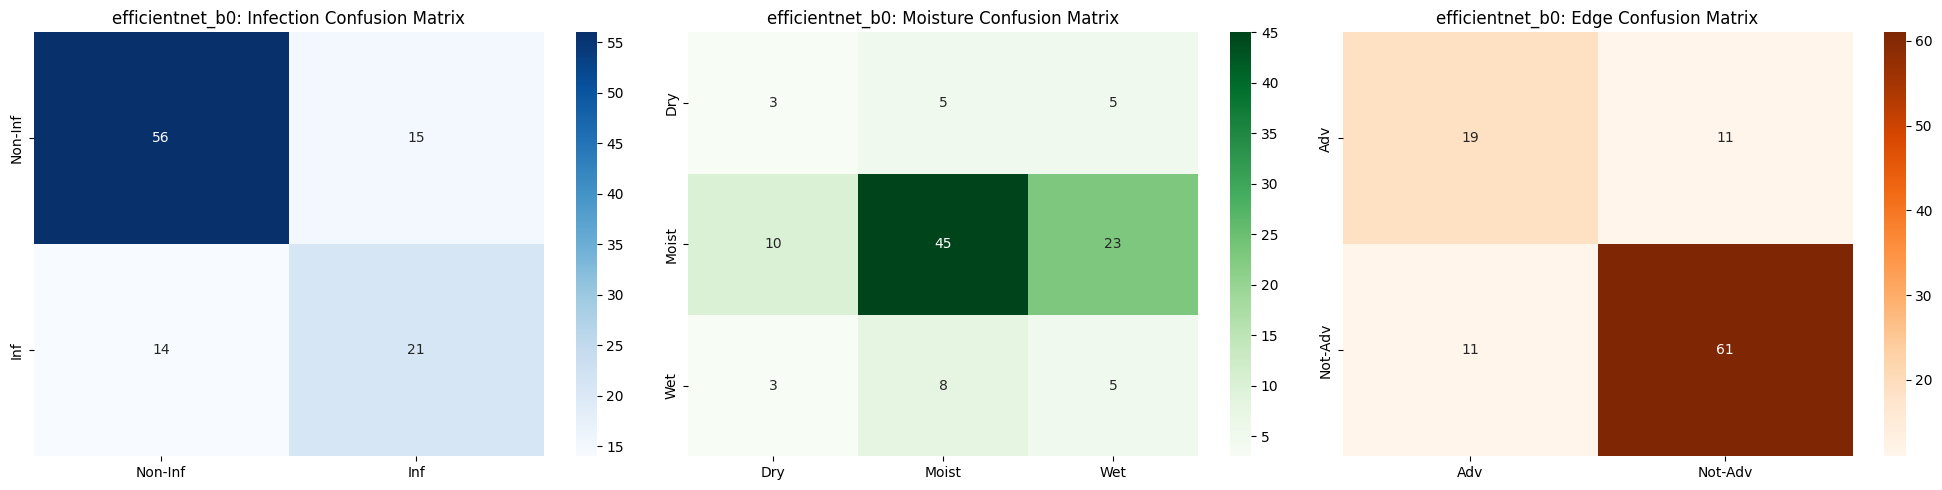



============================== ARCHITECTURE: RESNET50 ==============================

--- RESNET50 Final Summary ---
              Metric  Infection          Moisture   Edge
            Accuracy     0.6981            0.7009 0.7059
Sensitivity (Recall)     0.4000 N/A (Multi-class) 0.8750
         Specificity     0.8451 N/A (Multi-class) 0.3000
      Macro F1-Score     0.6281            0.4409 0.5913


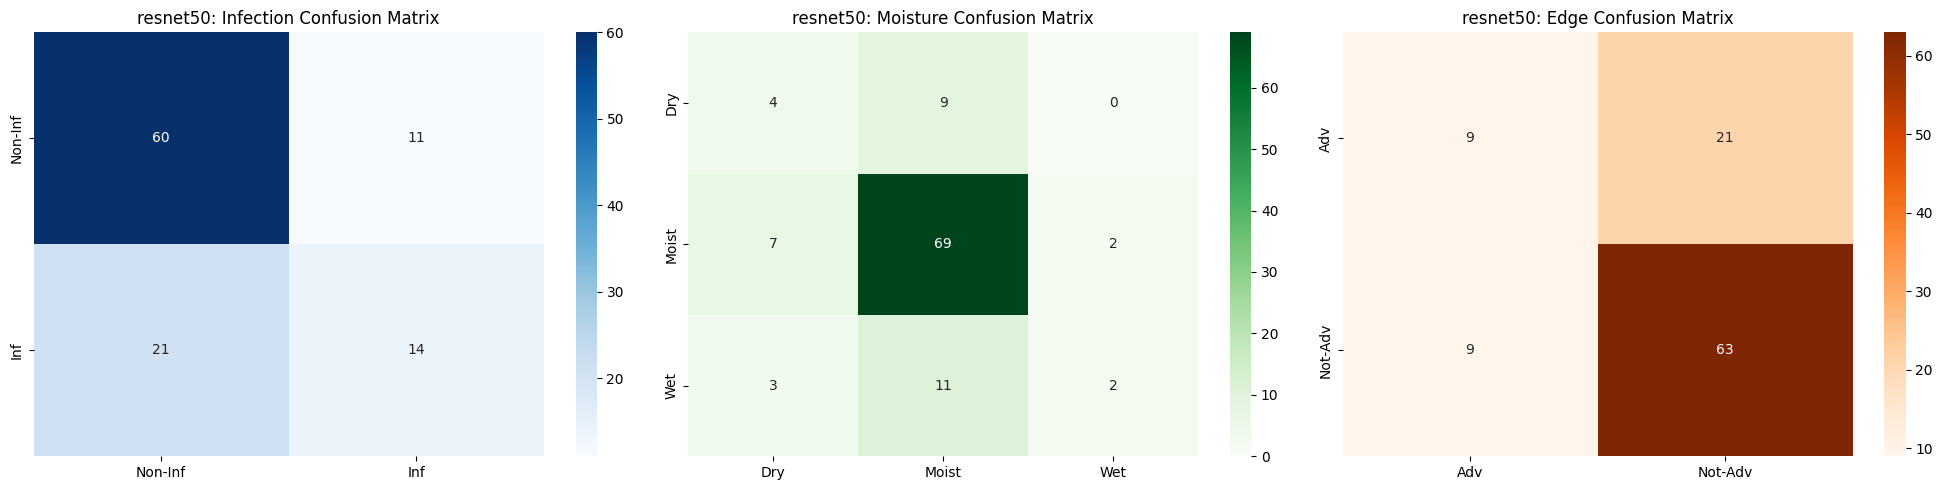



============================== ARCHITECTURE: MOBILENET_V3 ==============================

--- MOBILENET_V3 Final Summary ---
              Metric  Infection          Moisture   Edge
            Accuracy     0.6698            0.5607 0.7059
Sensitivity (Recall)     0.2286 N/A (Multi-class) 0.9028
         Specificity     0.8873 N/A (Multi-class) 0.2333
      Macro F1-Score     0.5482            0.3655 0.5653


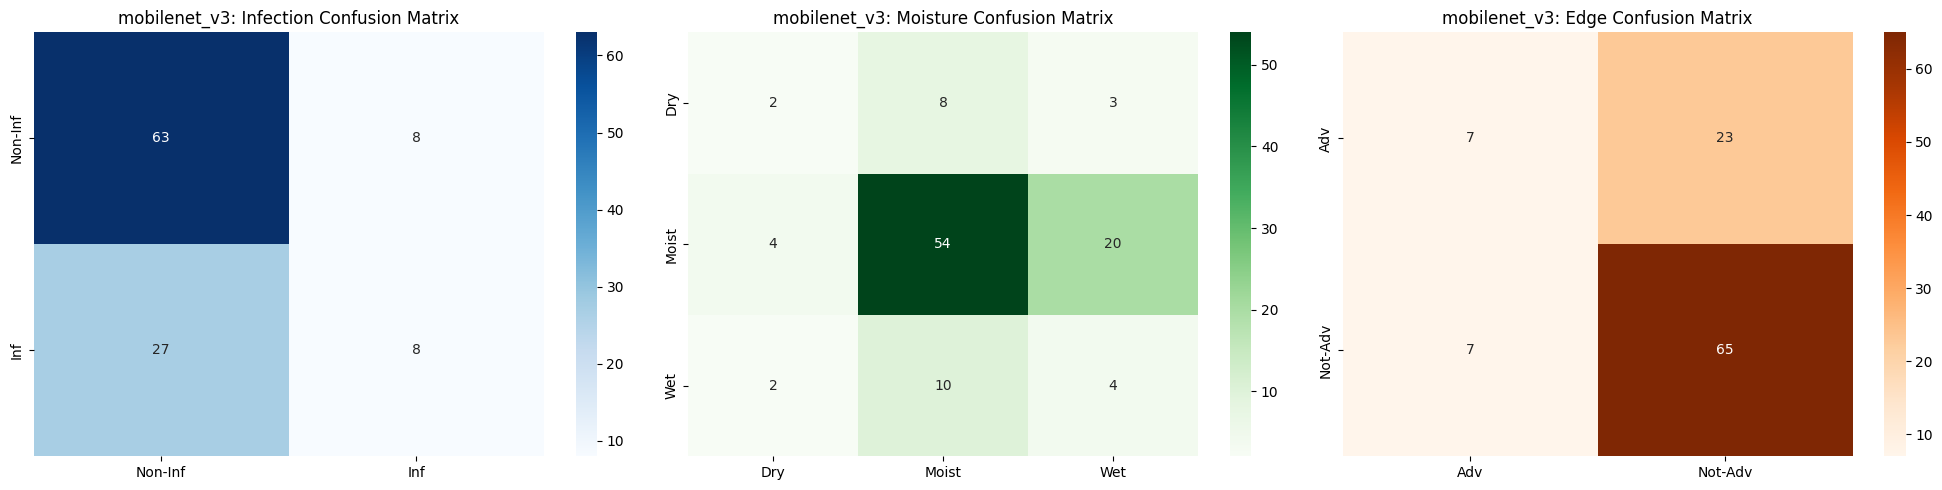



============================== ARCHITECTURE: SWIN_T ==============================

--- SWIN_T Final Summary ---
              Metric  Infection          Moisture   Edge
            Accuracy     0.6415            0.6822 0.7157
Sensitivity (Recall)     0.4571 N/A (Multi-class) 0.8472
         Specificity     0.7324 N/A (Multi-class) 0.4000
      Macro F1-Score     0.5948            0.4326 0.6304


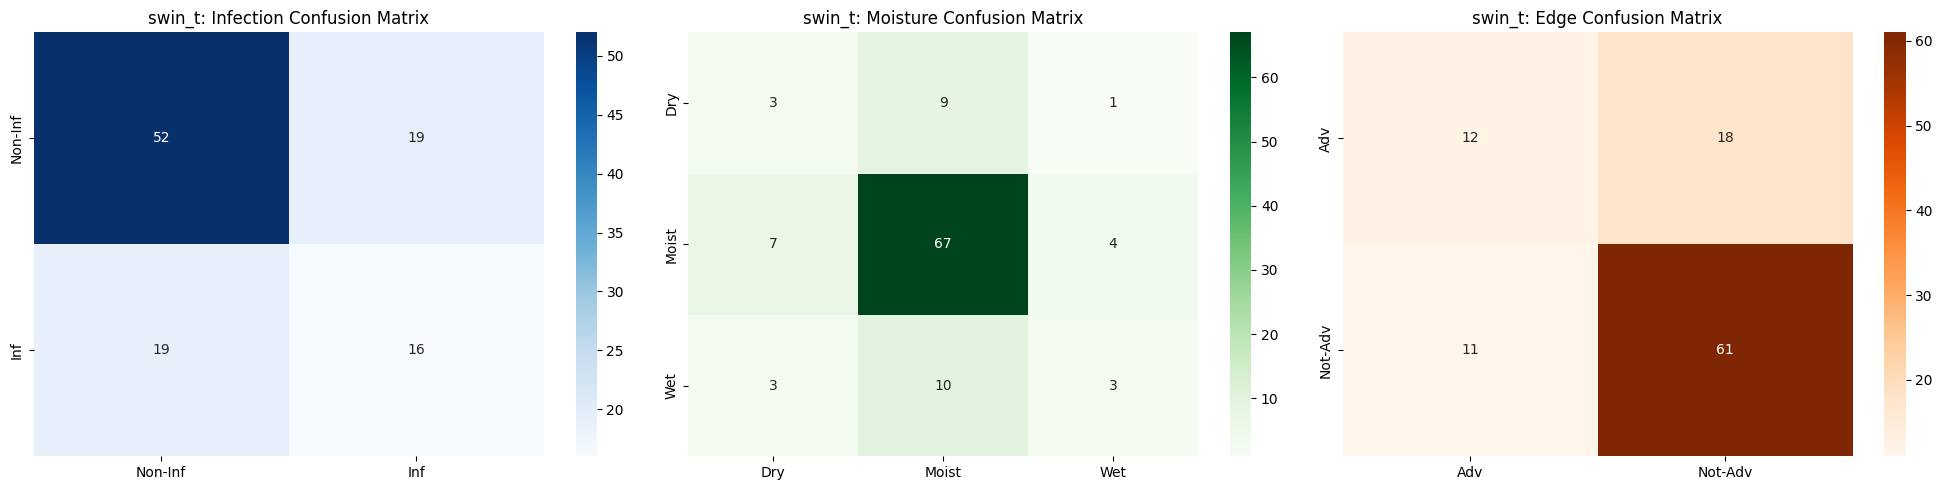

In [ ]:
target_names = {'inf': ["Non-Inf", "Inf"], 'moist': ["Dry", "Moist", "Wet"], 'edge': ["Adv", "Not-Adv"]}

for name in model_families:
    print(f"\n\n{'='*30} ARCHITECTURE: {name.upper()} {'='*30}")

    # Run inference and gather all predictions
    results = run_full_evaluation(name, df_expert)

    # Generate and Display Table
    summary_table = get_medical_table(results['true'], results['pred'], name)
    print(f"\n{name.upper()} Final Summary")
    print(summary_table.to_string(index=False))

    # Generate and Display Visual Confusion Matrices
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    tasks = [('inf', 'Infection', 'Blues'), ('moist', 'Moisture', 'Greens'), ('edge', 'Edge', 'Oranges')]

    for i, (key, title, color) in enumerate(tasks):
        cm = confusion_matrix(results['true'][key], results['pred'][key])
        sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                    xticklabels=target_names[key], yticklabels=target_names[key], ax=axes[i])
        axes[i].set_title(f'{name}: {title} Confusion Matrix')

    plt.tight_layout()
    plt.show()

In [ ]:
# FINAL COMPARISON TABLE

all_model_summaries = []

print(" Generating Consolidated Master Comparison Table...")

for name in model_families:
    # Get the aggregate predictions across 5 folds
    results = run_full_evaluation(name, df_expert)

    # Extract specific values for the summary
    def get_task_stats(t, p, task_type='binary'):
        acc = accuracy_score(t, p)
        f1 = f1_score(t, p, average='macro')
        if task_type == 'binary':
            cm = confusion_matrix(t, p)
            tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0,0,0,0)
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            return acc, sens, spec, f1
        return acc, f1

    # Calculate metrics for each task
    acc_i, sens_i, spec_i, f1_i = get_task_stats(results['true']['inf'], results['pred']['inf'])
    acc_m, f1_m = get_task_stats(results['true']['moist'], results['pred']['moist'], task_type='multi')
    acc_e, sens_e, spec_e, f1_e = get_task_stats(results['true']['edge'], results['pred']['edge'])

    # Create a clean dictionary for this model
    all_model_summaries.append({
        'Model Backbone': name.upper(),
        'Inf_F1': f1_i,
        'Inf_Sens': sens_i,
        'Inf_Spec': spec_i,
        'Moist_F1': f1_m,
        'Moist_Acc': acc_m,
        'Edge_F1': f1_e,
        'Edge_Sens': sens_e,
        'Edge_Spec': spec_e
    })

# Create the final DataFrame
master_df = pd.DataFrame(all_model_summaries)

# Round to 4 decimal places for professional formatting
master_df = master_df.round(4)

print("\n FINAL ARCHITECTURAL MASTER COMPARISON")
print(master_df.to_string(index=False))

📊 Generating Consolidated Master Comparison Table...

--- FINAL ARCHITECTURAL MASTER COMPARISON ---
 Model Backbone  Inf_F1  Inf_Sens  Inf_Spec  Moist_F1  Moist_Acc  Edge_F1  Edge_Sens  Edge_Spec
EFFICIENTNET_B0  0.6929    0.6000    0.7887    0.3576     0.4953   0.7403     0.8472     0.6333
       RESNET50  0.6281    0.4000    0.8451    0.4409     0.7009   0.5913     0.8750     0.3000
   MOBILENET_V3  0.5482    0.2286    0.8873    0.3655     0.5607   0.5653     0.9028     0.2333
         SWIN_T  0.5948    0.4571    0.7324    0.4326     0.6822   0.6304     0.8472     0.4000
